## Boosting Ensemble Method: Theory and Implementation

Boosting is a powerful ensemble learning technique that combines multiple weak learners (often simple decision trees) to create a strong learner. The core idea behind boosting is to sequentially build the ensemble, with each new learner focusing on correcting the errors made by the previous ones.

### How Boosting Works:

1.  **Start with a weak model**: An initial model (e.g., a shallow decision tree) is trained on the dataset.
2.  **Identify errors**: The model's predictions are compared to the actual values, and the samples that were misclassified or poorly predicted are given higher importance (or weight).
3.  **Train a new model**: A new weak model is trained, specifically focusing on these 'difficult' samples.
4.  **Combine models**: The new model is added to the ensemble, and its contribution is weighted based on its performance.
5.  **Iterate**: Steps 2-4 are repeated for a predefined number of iterations or until a certain performance threshold is met.

The final prediction is a weighted sum or vote of all the individual weak learners.

### Advantages of Boosting:

*   **High Accuracy**: Often achieves higher accuracy than individual weak learners and even other ensemble methods like Bagging.
*   **Handles Bias**: Reduces bias effectively by focusing on misclassified samples.

### Disadvantages of Boosting:

*   **Prone to Overfitting**: Can be prone to overfitting if not carefully tuned, especially with noisy data.
*   **Computationally Intensive**: Sequential training can be slower than parallel methods.
*   **Sensitive to Outliers**: Outliers can disproportionately influence the model's performance.

### Common Boosting Algorithms:

1.  **AdaBoost (Adaptive Boosting)**: Adjusts weights of misclassified samples and of the weak learners themselves.
2.  **Gradient Boosting**: Builds new models that predict the residuals or errors of prior models, then adds these predictions to make the final prediction.
3.  **XGBoost, LightGBM, CatBoost**: Highly optimized and scalable implementations of gradient boosting.

---

### Step 1: Generate a Synthetic Dataset

Let's create a simple classification dataset using `scikit-learn` to demonstrate the boosting methods.

Training data shape: (350, 2)
Testing data shape: (150, 2)


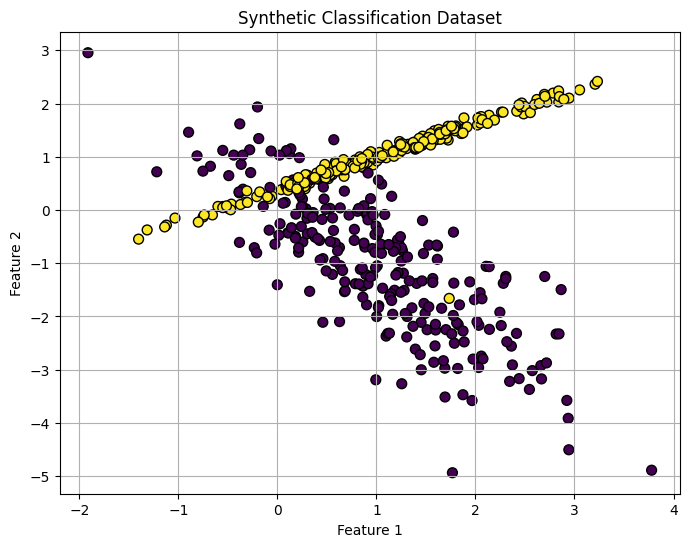

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Generate a synthetic dataset
X, y = make_classification(n_samples=500, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1, random_state=42)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Visualize the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, edgecolors='k')
plt.title('Synthetic Classification Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

### Step 2: Implement AdaBoost

**AdaBoost (Adaptive Boosting)** is one of the first successful boosting algorithms. It works by training a series of weak learners sequentially. In each step, the algorithm re-weights the training samples, giving more importance to those that were misclassified by the previous learners. It also assigns a weight to each learner based on its accuracy, and the final prediction is a weighted majority vote of all learners.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize a base estimator (weak learner), e.g., a shallow Decision Tree
# Max_depth=1 makes it a decision stump, which is common for AdaBoost.
base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)

# Initialize AdaBoostClassifier
adaboost_model = AdaBoostClassifier(estimator=base_estimator, n_estimators=50, random_state=42)

# Train the AdaBoost model
adaboost_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_adaboost = adaboost_model.predict(X_test)

# Evaluate the model
print("#### AdaBoost Classifier Results ####")
print(f"Accuracy: {accuracy_score(y_test, y_pred_adaboost):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_adaboost))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_adaboost))

#### AdaBoost Classifier Results ####
Accuracy: 0.8600

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86        75
           1       0.85      0.88      0.86        75

    accuracy                           0.86       150
   macro avg       0.86      0.86      0.86       150
weighted avg       0.86      0.86      0.86       150


Confusion Matrix:
[[63 12]
 [ 9 66]]


### Step 3: Implement Gradient Boosting

**Gradient Boosting** is another popular boosting technique. Instead of adjusting instance weights, Gradient Boosting builds new trees that predict the residuals (the differences between the actual values and the predictions of the previous models). Each new tree tries to correct the errors of the ensemble built so far. The predictions of all trees are then summed up to get the final prediction.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize GradientBoostingClassifier
# n_estimators: number of boosting stages (number of trees)
# learning_rate: shrinks the contribution of each tree
# max_depth: limits the number of nodes in the tree
gradient_boosting_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Train the Gradient Boosting model
gradient_boosting_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_gradient_boosting = gradient_boosting_model.predict(X_test)

# Evaluate the model
print("#### Gradient Boosting Classifier Results ####")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gradient_boosting):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gradient_boosting))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gradient_boosting))

#### Gradient Boosting Classifier Results ####
Accuracy: 0.9467

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.93      0.95        75
           1       0.94      0.96      0.95        75

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150


Confusion Matrix:
[[70  5]
 [ 3 72]]


### Step 4: Compare Results

Let's summarize and compare the accuracy of both boosting models on our synthetic dataset.

In [ ]:
adaboost_accuracy = accuracy_score(y_test, y_pred_adaboost)
gradient_boosting_accuracy = accuracy_score(y_test, y_pred_gradient_boosting)

print(f"AdaBoost Classifier Accuracy: {adaboost_accuracy:.4f}")
print(f"Gradient Boosting Classifier Accuracy: {gradient_boosting_accuracy:.4f}")

if gradient_boosting_accuracy > adaboost_accuracy:
    print("\nIn this specific case, Gradient Boosting performed slightly better than AdaBoost.")
elif adaboost_accuracy > gradient_boosting_accuracy:
    print("\nIn this specific case, AdaBoost performed slightly better than Gradient Boosting.")
else:
    print("\nBoth AdaBoost and Gradient Boosting achieved similar accuracy in this case.")

print("\nIt's important to note that performance can vary greatly depending on the dataset and hyperparameter tuning.")

AdaBoost Classifier Accuracy: 0.8600
Gradient Boosting Classifier Accuracy: 0.9467

In this specific case, Gradient Boosting performed slightly better than AdaBoost.

It's important to note that performance can vary greatly depending on the dataset and hyperparameter tuning.
